In [2]:
#Config & Setup (Amazon Product Metadata)


import os
import pandas as pd
from pathlib import Path
from datasets import load_dataset
import random

# Reproducibility
random.seed(42)

# Base Hugging Face repo for metadata
HF_REPO = "McAuley-Lab/Amazon-Reviews-2023"
CATEGORIES = ["All_Beauty", "Electronics", "Books"]
SAMPLES_PER_CATEGORY = 30000  # adjustable depending on memory

# Output directory
OUTPUT_DIR = Path("notebooks/data/processed/amazon_product_meta")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Columns to extract (depends on file structure)
META_COLUMNS = [
    "asin",
    "title",
    "description",
    "price",
    "category",
    "brand",
    "feature_bullets",
    "average_rating"
]

print("=== Product Intelligence Config ===")
print(f"Categories: {CATEGORIES}")
print(f"Samples per category: {SAMPLES_PER_CATEGORY}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Columns to keep: {META_COLUMNS}")


=== Product Intelligence Config ===
Categories: ['All_Beauty', 'Electronics', 'Books']
Samples per category: 30000
Output directory: notebooks/data/processed/amazon_product_meta
Columns to keep: ['asin', 'title', 'description', 'price', 'category', 'brand', 'feature_bullets', 'average_rating']


In [3]:
#Stream & Sample Product Metadata

import json
import requests

def stream_and_sample_metadata(category, n_samples=30000):
    """
    Stream metadata from Hugging Face repo for a given category
    and sample a subset of items.
    """
    base_url = f"https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_{category}.jsonl"
    print(f"\nStreaming metadata for {category}")
    print(f"URL: {base_url}")

    records = []
    try:
        with requests.get(base_url, stream=True, timeout=60) as r:
            for i, line in enumerate(r.iter_lines()):
                if line:
                    try:
                        rec = json.loads(line)
                        records.append(rec)
                    except json.JSONDecodeError:
                        continue
                if len(records) >= n_samples:
                    break
    except Exception as e:
        print(f"Error streaming {category}: {e}")
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df["category"] = category
    print(f"Retrieved {len(df)} items for {category}")
    return df


# Collect and combine metadata
meta_dfs = []
for cat in CATEGORIES:
    df_cat = stream_and_sample_metadata(cat, n_samples=SAMPLES_PER_CATEGORY)
    if not df_cat.empty:
        meta_dfs.append(df_cat)

if meta_dfs:
    df_meta = pd.concat(meta_dfs, ignore_index=True)
    out_path = OUTPUT_DIR / "amazon_product_meta_raw.parquet"
    df_meta.to_parquet(out_path, index=False)
    print(f"\nCombined shape: {df_meta.shape}")
    print(f"Saved raw metadata: {out_path}")
else:
    print("\nNo data retrieved. Check URLs or category names.")



Streaming metadata for All_Beauty
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_All_Beauty.jsonl
Retrieved 30000 items for All_Beauty

Streaming metadata for Electronics
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Electronics.jsonl
Retrieved 30000 items for Electronics

Streaming metadata for Books
URL: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Books.jsonl
Retrieved 30000 items for Books

Combined shape: (90000, 17)
Saved raw metadata: notebooks/data/processed/amazon_product_meta/amazon_product_meta_raw.parquet


In [5]:
# Cell 3 (Safe Version — Handles Missing Columns)

import pandas as pd
import numpy as np
import re
from pathlib import Path
from tqdm import tqdm
import pyarrow.parquet as pq

raw_path = OUTPUT_DIR / "amazon_product_meta_raw.parquet"
print(f"Streaming parquet: {raw_path}")

# Precompile regex
html_re = re.compile(r"<.*?>")
non_alnum_re = re.compile(r"[^a-zA-Z0-9\s.,!?]")
multi_space_re = re.compile(r"\s+")

def clean_text(txt):
    if not isinstance(txt, str) or not txt.strip():
        return ""
    txt = html_re.sub("", txt)
    txt = non_alnum_re.sub("", txt)
    txt = multi_space_re.sub(" ", txt).strip().lower()
    return txt

# Read available columns dynamically
dataset = pq.ParquetFile(raw_path)
available_cols = dataset.schema.names
desired_cols = ["asin", "title", "description", "price", "brand", "average_rating", "category"]
columns = [c for c in desired_cols if c in available_cols]

print(f"Columns found: {columns}")

cleaned_batches = []
for batch in tqdm(dataset.iter_batches(batch_size=5000, columns=columns), desc="Cleaning batches"):
    df = batch.to_pandas()
    for col in ["title", "description"]:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(clean_text)
    if "price" in df.columns:
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
    if "average_rating" in df.columns:
        df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
    if "brand" in df.columns:
        df["brand"].fillna("unknown", inplace=True)
    df.dropna(subset=[c for c in ["title", "description"] if c in df.columns], inplace=True)
    cleaned_batches.append(df)

# Combine batches
df_meta = pd.concat(cleaned_batches, ignore_index=True)
print(f"\nCombined after cleaning: {df_meta.shape}")

# Fill numeric missing values
if "price" in df_meta.columns:
    df_meta["price"].fillna(df_meta["price"].median(), inplace=True)
if "average_rating" in df_meta.columns:
    df_meta["average_rating"].fillna(df_meta["average_rating"].mean(), inplace=True)

# Save cleaned version
cleaned_path = OUTPUT_DIR / "amazon_product_meta_cleaned.parquet"
df_meta.to_parquet(cleaned_path, index=False)
print(f"\nSaved cleaned dataset: {cleaned_path}")
print(df_meta.sample(3, random_state=42))


Streaming parquet: notebooks/data/processed/amazon_product_meta/amazon_product_meta_raw.parquet
Columns found: ['title', 'price', 'average_rating', 'category']


Cleaning batches: 18it [00:00, 49.64it/s]
/tmp/ipykernel_25830/1832294299.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_meta["price"].fillna(df_meta["price"].median(), inplace=True)
/tmp/ipykernel_25830/1832294299.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e


Combined after cleaning: (90000, 4)

Saved cleaned dataset: notebooks/data/processed/amazon_product_meta/amazon_product_meta_cleaned.parquet
                                                   title  price  \
89610                       the perfect cupcake a momoir  15.00   
12456  ausrialian gold smooth faces facial intensifie...  26.00   
53403  replacement for olympus stylus sz16 charger co...   5.99   

       average_rating     category  
89610             4.8        Books  
12456             4.6   All_Beauty  
53403             4.3  Electronics  


Loaded cleaned metadata: notebooks/data/processed/amazon_product_meta/amazon_product_meta_cleaned.parquet
Shape: (90000, 4)

Columns: ['title', 'price', 'average_rating', 'category']

=== Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           90000 non-null  object 
 1   price           90000 non-null  float64
 2   average_rating  90000 non-null  float64
 3   category        90000 non-null  object 
dtypes: float64(2), object(2)
memory usage: 2.7+ MB
None

=== Numeric Summary ===
          price  average_rating
count  90000.00        90000.00
mean      28.44            4.13
std      121.93            0.75
min        0.00            1.00
25%       14.99            3.80
50%       15.00            4.30
75%       15.84            4.60
max    12998.00            5.00

=== Category Counts ===
category
All_Beauty  

/tmp/ipykernel_25830/2127636658.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_meta, x="category", palette="viridis")


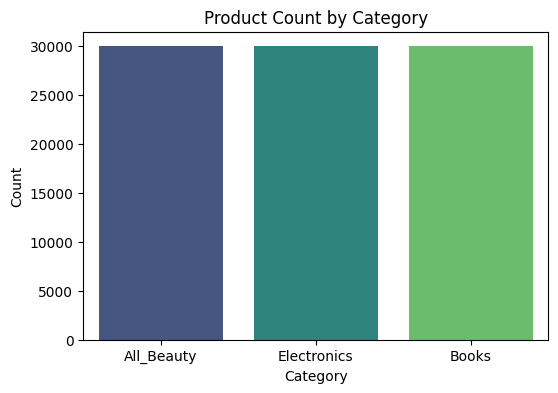

/tmp/ipykernel_25830/2127636658.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_meta, x="category", y="price", palette="mako")


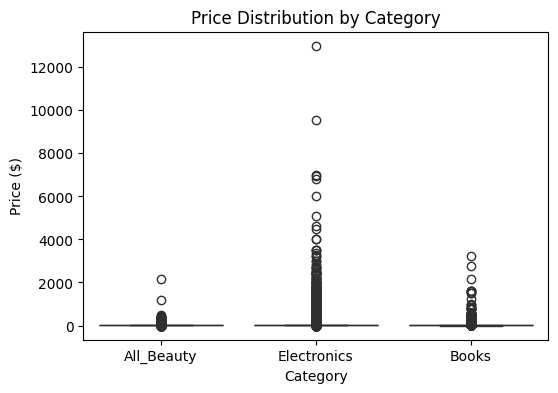

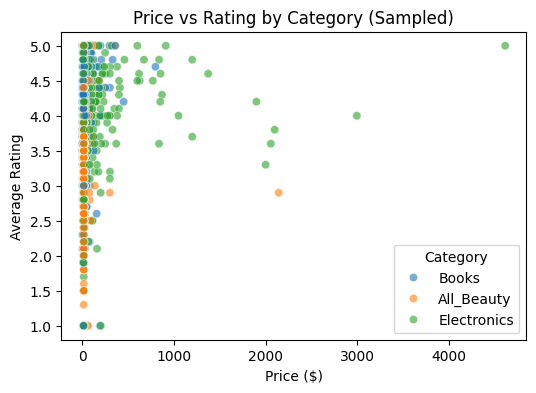

In [7]:
# ============================================
# Cell 4 — Product Intelligence EDA Summary (Fixed)
# ============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned data
cleaned_path = OUTPUT_DIR / "amazon_product_meta_cleaned.parquet"
df_meta = pd.read_parquet(cleaned_path)

print(f"Loaded cleaned metadata: {cleaned_path}")
print("Shape:", df_meta.shape)
print("\nColumns:", df_meta.columns.tolist())

# Basic info
print("\n=== Data Overview ===")
print(df_meta.info())

# --- Numeric Summary (safe for all pandas versions) ---
num_cols = df_meta.select_dtypes(include=["int64", "float64"]).columns
print("\n=== Numeric Summary ===")
print(df_meta[num_cols].describe().round(2))

# Category distribution
print("\n=== Category Counts ===")
print(df_meta["category"].value_counts())

# --- Visualizations ---
plt.figure(figsize=(6,4))
sns.countplot(data=df_meta, x="category", palette="viridis")
plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df_meta, x="category", y="price", palette="mako")
plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price ($)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_meta.sample(min(5000, len(df_meta)), random_state=42),
    x="price", y="average_rating", hue="category", alpha=0.6
)
plt.title("Price vs Rating by Category (Sampled)")
plt.xlabel("Price ($)")
plt.ylabel("Average Rating")
plt.legend(title="Category")
plt.show()
